# Phase 8 — Data Visualization

## Introduction

This phase focuses on visually communicating the key findings identified during the Exploratory Data Analysis (EDA) in Phase 7 of the Meridian Retail Group customer churn investigation. The purpose of the visualization stage is to transform the analytical results into clear and interpretable charts that can support business decision-making.

The visualizations examine customer churn patterns across different customer segments and investigate relationships between churn and important behavioural and customer-experience variables. These include membership tier, preferred channel, purchase recency, purchase frequency, monetary value, and support-ticket activity.

Both static and interactive visualizations are produced. Matplotlib is used to create publication-ready charts for overall churn distribution, RFM characteristics, support-ticket activity, and relationships among important variables. Plotly is used to create interactive visualizations that allow deeper exploration of customer segments and relationships between variables.

The visual analysis is based on the customer-level dataset produced in Phase 7. This ensures that Phase 8 builds directly on the previously engineered churn, RFM, and support-ticket features rather than repeating the analysis.

The main objectives of this phase are to:

1. Visually communicate the overall distribution of customer churn.
2. Compare churn rates across important customer segments.
3. Examine RFM patterns associated with customer churn.
4. Investigate the relationship between support-ticket activity and customer status.
5. Explore multivariate relationships among churn, customer value, purchasing behaviour, and customer-service variables.
6. Identify visual patterns that can support practical customer-retention strategies.

The outputs from this phase will provide a visual evidence base for the subsequent Machine Learning phase, where predictive models will be developed to identify customers who may be at increased risk of churn.


## Visualization Approach

The analysis will use the final customer-level dataset generated in Phase 7. The visualization workflow will include:

* **Matplotlib visualizations** for static exploratory and presentation-ready charts.
* **Plotly visualizations** for interactive exploration of customer behaviour.
* **RFM visualizations** to examine recency, frequency, and monetary value.
* **Customer-segment visualizations** to compare churn across membership tiers and channels.
* **Support-ticket visualizations** to investigate customer-service activity and satisfaction.
* **Correlation analysis** to explore relationships among the major numerical variables.

All charts will include appropriate titles, axis labels, and legends where necessary. The resulting visualizations will be saved in the project's `Data/Phase 8 Visualization` folder for documentation and later reporting.


In [2]:
# ============================================================
# PHASE 8 — DATA VISUALIZATION
# ============================================================

print("=" * 80)
print("PHASE 8 — DATA VISUALIZATION")
print("Meridian Retail Group Customer Churn Investigation")
print("=" * 80)

print("\nObjective:")
print(
    "To visually communicate the key churn, RFM, customer segment, "
    "and support-ticket patterns identified during Phase 7."
)

PHASE 8 — DATA VISUALIZATION
Meridian Retail Group Customer Churn Investigation

Objective:
To visually communicate the key churn, RFM, customer segment, and support-ticket patterns identified during Phase 7.


In [3]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# ============================================================
# CELL 3 — CHECK GOOGLE DRIVE CONNECTION
# ============================================================

import os

if os.path.exists("/content/drive/MyDrive"):
    print("Google Drive is already mounted and ready.")
else:
    from google.colab import drive
    drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

PROJECT_PATH = (
    "/content/drive/MyDrive/"
    "Meridian Retail Group - Customer Churn Capstone"
)

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "Data"
)

PHASE7_PATH = os.path.join(
    DATA_PATH,
    "Phase 7 Analysis"
)

PHASE8_PATH = os.path.join(
    DATA_PATH,
    "Phase 8 Visualization"
)

# Create Phase 8 folder if it does not already exist
os.makedirs(
    PHASE8_PATH,
    exist_ok=True
)

print("Project path:")
print(PROJECT_PATH)

print("\nPhase 7 path:")
print(PHASE7_PATH)

print("\nPhase 8 path:")
print(PHASE8_PATH)

Project path:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone

Phase 7 path:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 7 Analysis

Phase 8 path:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization


In [6]:
# ============================================================
# CELL 5 — LOAD PHASE 7 CUSTOMER ANALYSIS
# ============================================================

customer_analysis_file = os.path.join(
    PHASE7_PATH,
    "customer_churn_analysis.csv"
)

customer_analysis = pd.read_csv(
    customer_analysis_file
)

print("=" * 70)
print("PHASE 7 CUSTOMER ANALYSIS LOADED")
print("=" * 70)

print("\nShape:")
print(customer_analysis.shape)

print("\nColumns:")
print(customer_analysis.columns.tolist())

PHASE 7 CUSTOMER ANALYSIS LOADED

Shape:
(6090, 36)

Columns:
['customer_id', 'first_name', 'last_name', 'email', 'phone', 'gender', 'date_of_birth', 'signup_date', 'state', 'city', 'membership_tier', 'preferred_channel', 'marketing_opt_in', 'referral_source', 'Age', 'Age_Group', 'Order_Count', 'Total_Revenue', 'Customer_Segment', 'Revenue_ZScore', 'Revenue_Outlier', 'Ticket_Count', 'Average_Satisfaction_original', 'Satisfaction_Missing', 'Last_Completed_Order', 'Signup_Cohort', 'Recency_Days', 'Churn', 'Churn_Label', 'Frequency', 'Monetary_Total', 'Monetary_Average', 'Support_Ticket_Count', 'Average_Satisfaction', 'Average_Resolution_Time', 'Customer_Status']


In [7]:
# ============================================================
# CELL 6 — VALIDATE PHASE 7 DATA
# ============================================================

print("=" * 70)
print("DATA VALIDATION")
print("=" * 70)

print("\nNumber of customers:")
print(customer_analysis["customer_id"].nunique())

print("\nChurn labels:")
print(
    customer_analysis["Churn_Label"]
    .value_counts(dropna=False)
)

print("\nCustomer status:")
print(
    customer_analysis["Customer_Status"]
    .value_counts(dropna=False)
)

print("\nMissing values in key visualization columns:")

visualization_columns = [
    "Churn_Label",
    "Customer_Status",
    "Recency_Days",
    "Frequency",
    "Monetary_Total",
    "Monetary_Average",
    "Support_Ticket_Count",
    "Average_Satisfaction",
    "Average_Resolution_Time"
]

display(
    customer_analysis[
        visualization_columns
    ].isnull().sum()
)

DATA VALIDATION

Number of customers:
6090

Churn labels:
Churn_Label
Churned    4072
Active     2018
Name: count, dtype: int64

Customer status:
Customer_Status
Churned        4072
Not Churned    2018
Name: count, dtype: int64

Missing values in key visualization columns:


,0
Churn_Label,0
Customer_Status,0
Recency_Days,447
Frequency,0
Monetary_Total,0
Monetary_Average,0
Support_Ticket_Count,2561
Average_Satisfaction,2843
Average_Resolution_Time,2563


In [8]:
# ============================================================
# CELL 7 — CREATE NUMERIC CHURN FLAG
# ============================================================

customer_analysis["Churn_Flag"] = (
    customer_analysis["Churn_Label"]
    .map({
        "Churned": 1,
        "Active": 0
    })
)

print("Churn flag created.")

print(
    customer_analysis[
        ["Churn_Label", "Churn_Flag"]
    ].head()
)

Churn flag created.
  Churn_Label  Churn_Flag
0      Active           0
1     Churned           1
2     Churned           1
3     Churned           1
4     Churned           1


In [9]:
# ============================================================
# CELL 8 — VISUALIZATION HELPER FUNCTION
# ============================================================

def save_matplotlib_chart(filename):
    """
    Saves the current Matplotlib figure
    into the Phase 8 Visualization folder.
    """

    file_path = os.path.join(
        PHASE8_PATH,
        filename
    )

    plt.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Chart saved: {file_path}")

Chart saved: /content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/01_overall_churn_distribution.png


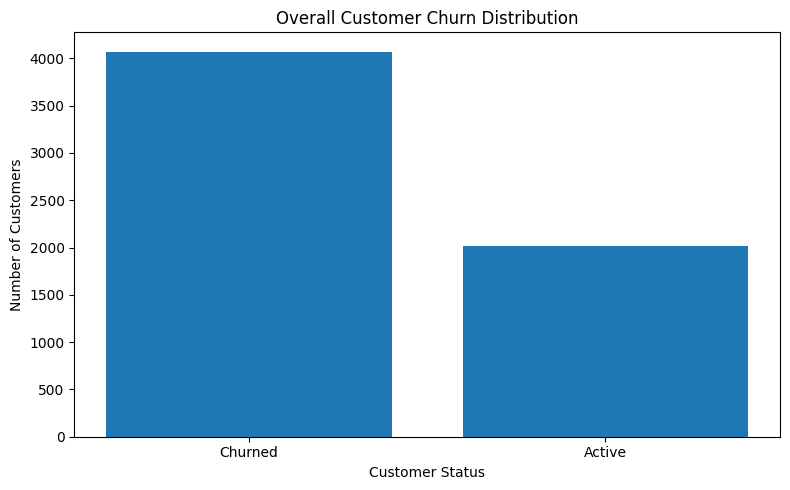

In [10]:
# ============================================================
# CELL 9 — MATPLOTLIB 1
# OVERALL CUSTOMER CHURN DISTRIBUTION
# ============================================================

churn_counts = (
    customer_analysis["Churn_Label"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title(
    "Overall Customer Churn Distribution"
)

plt.xlabel(
    "Customer Status"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

save_matplotlib_chart(
    "01_overall_churn_distribution.png"
)

plt.show()

Interpretation

This chart shows the number of customers classified as Churned versus Active using the 180-day inactivity definition established in Phase 7

Chart saved: /content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/02_churn_rate_by_membership_tier.png


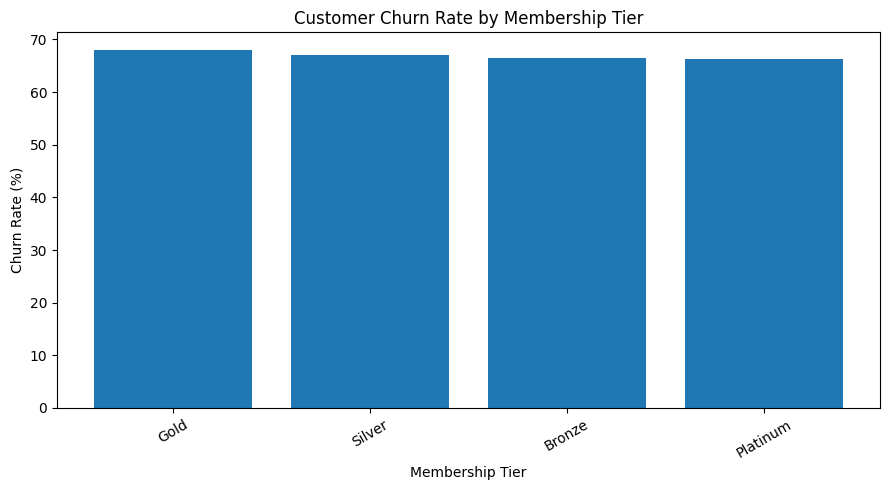

In [11]:
# ============================================================
# CELL 10 — MATPLOTLIB 2
# CHURN RATE BY MEMBERSHIP TIER
# ============================================================

tier_churn = (
    customer_analysis
    .groupby("membership_tier")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    tier_churn.index.astype(str),
    tier_churn.values
)

plt.title(
    "Customer Churn Rate by Membership Tier"
)

plt.xlabel(
    "Membership Tier"
)

plt.ylabel(
    "Churn Rate (%)"
)

plt.xticks(rotation=30)

plt.tight_layout()

save_matplotlib_chart(
    "02_churn_rate_by_membership_tier.png"
)

plt.show()

Interpretation

This visualization allows Meridian to identify whether customer loyalty differs across membership tiers.

A noticeably higher churn rate in a particular tier would suggest that the benefits, engagement strategy, or customer experience associated with that tier may require investigation.

Chart saved: /content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/03_recency_distribution.png


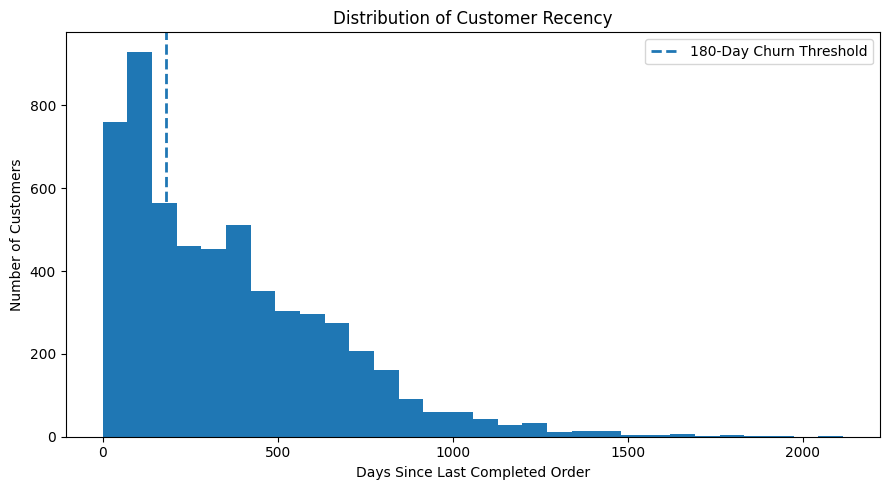

In [12]:
# ============================================================
# CELL 11 — MATPLOTLIB 3
# RECENCY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    customer_analysis["Recency_Days"].dropna(),
    bins=30
)

plt.axvline(
    180,
    linestyle="--",
    linewidth=2,
    label="180-Day Churn Threshold"
)

plt.title(
    "Distribution of Customer Recency"
)

plt.xlabel(
    "Days Since Last Completed Order"
)

plt.ylabel(
    "Number of Customers"
)

plt.legend()

plt.tight_layout()

save_matplotlib_chart(
    "03_recency_distribution.png"
)

plt.show()

Interpretation

The chart shows how recently customers made their last completed purchase.

The vertical reference line at 180 days represents the churn threshold used in the project. Customers beyond this threshold are classified as churned.

Chart saved: /content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/04_frequency_by_churn_status.png


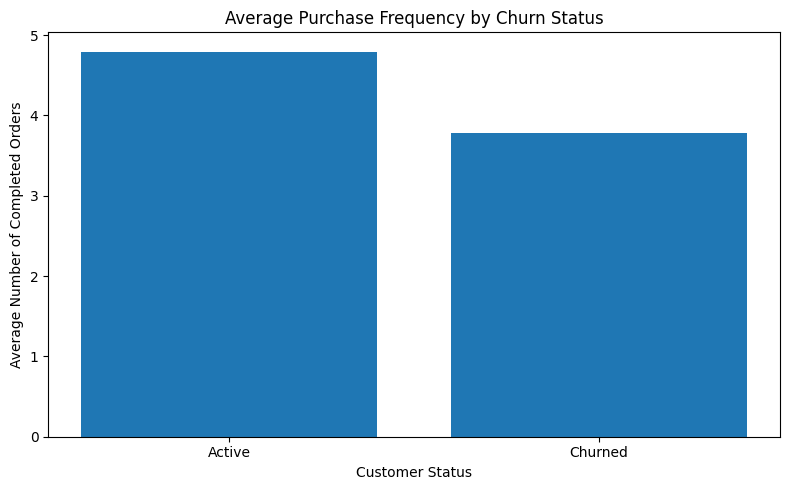

In [13]:
# ============================================================
# CELL 12 — MATPLOTLIB 4
# PURCHASE FREQUENCY BY CHURN STATUS
# ============================================================

frequency_data = (
    customer_analysis
    .groupby("Churn_Label")["Frequency"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    frequency_data.index,
    frequency_data.values
)

plt.title(
    "Average Purchase Frequency by Churn Status"
)

plt.xlabel(
    "Customer Status"
)

plt.ylabel(
    "Average Number of Completed Orders"
)

plt.tight_layout()

save_matplotlib_chart(
    "04_frequency_by_churn_status.png"
)

plt.show()

Interpretation

This visualization compares purchasing frequency between active and churned customers.

If churned customers have substantially lower purchase frequency, Meridian may need stronger repeat-purchase and customer-engagement strategies.

Chart saved: /content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/05_monetary_value_by_churn_status.png


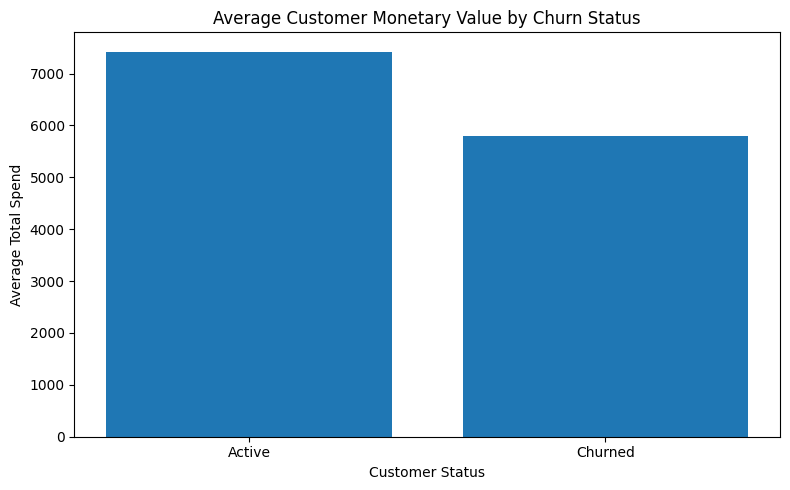

In [14]:
# ============================================================
# CELL 13 — MATPLOTLIB 5
# MONETARY VALUE BY CHURN STATUS
# ============================================================

monetary_data = (
    customer_analysis
    .groupby("Churn_Label")["Monetary_Total"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    monetary_data.index,
    monetary_data.values
)

plt.title(
    "Average Customer Monetary Value by Churn Status"
)

plt.xlabel(
    "Customer Status"
)

plt.ylabel(
    "Average Total Spend"
)

plt.tight_layout()

save_matplotlib_chart(
    "05_monetary_value_by_churn_status.png"
)

plt.show()

Interpretation

This chart examines whether churn is associated with customer monetary value.

This is useful because Meridian should not necessarily treat every churned customer as having the same business impact.

Chart saved: /content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/06_support_tickets_by_churn_status.png


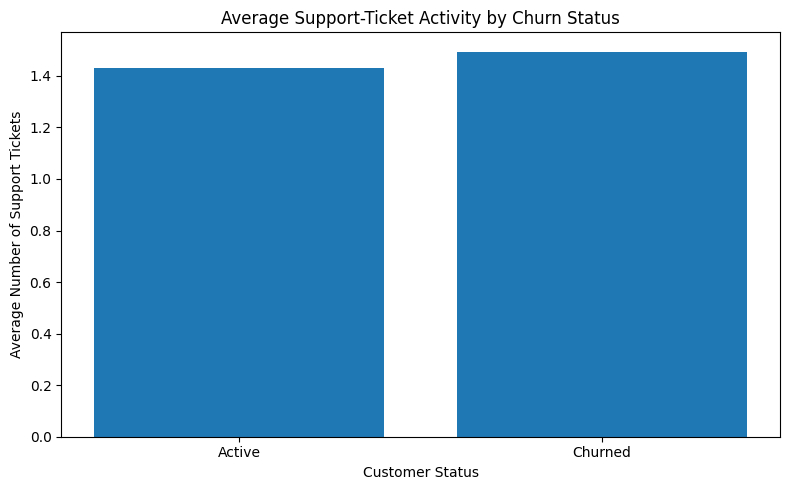

In [15]:
# ============================================================
# CELL 14 — MATPLOTLIB 6
# SUPPORT TICKETS BY CHURN STATUS
# ============================================================

support_data = (
    customer_analysis
    .groupby("Churn_Label")["Support_Ticket_Count"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    support_data.index,
    support_data.values
)

plt.title(
    "Average Support-Ticket Activity by Churn Status"
)

plt.xlabel(
    "Customer Status"
)

plt.ylabel(
    "Average Number of Support Tickets"
)

plt.tight_layout()

save_matplotlib_chart(
    "06_support_tickets_by_churn_status.png"
)

plt.show()

Interpretation

This chart investigates whether churned customers generated more support interactions than active customers.

A higher level of support activity among churned customers could indicate that unresolved customer-service problems are associated with retention risk.

Chart saved: /content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/07_correlation_heatmap.png


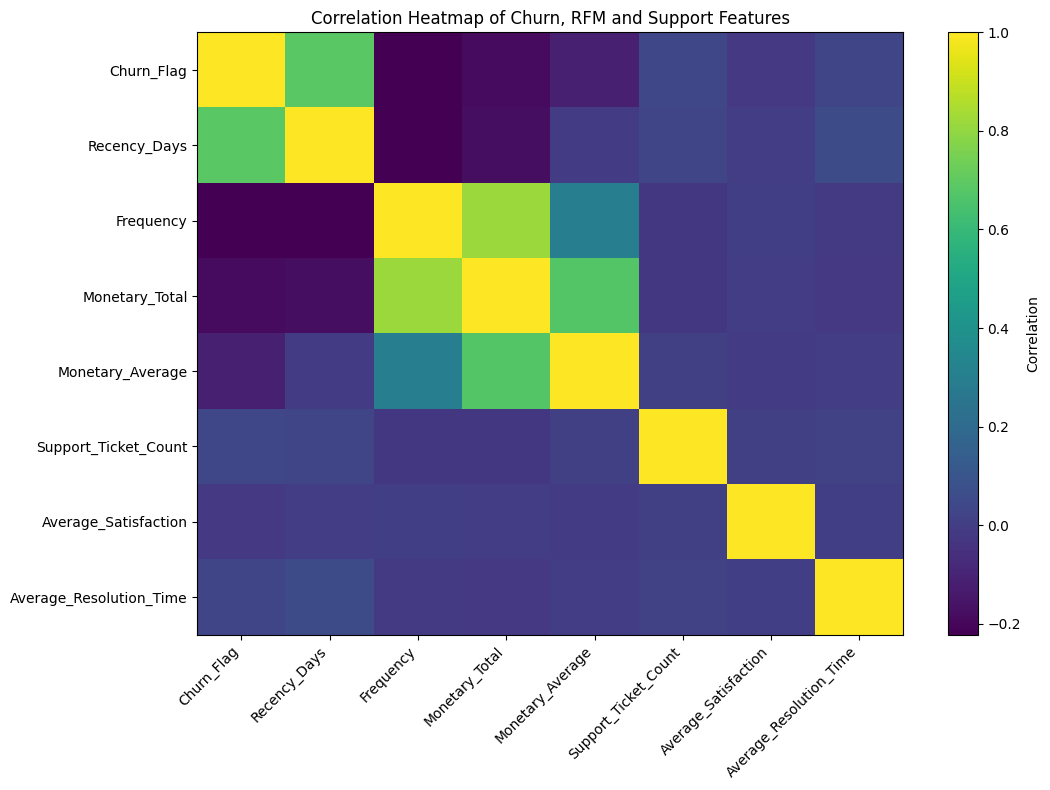

In [16]:
# ============================================================
# CELL 15 — MATPLOTLIB 7
# CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    "Churn_Flag",
    "Recency_Days",
    "Frequency",
    "Monetary_Total",
    "Monetary_Average",
    "Support_Ticket_Count",
    "Average_Satisfaction",
    "Average_Resolution_Time"
]

correlation_matrix = (
    customer_analysis[
        correlation_columns
    ]
    .corr()
)

plt.figure(figsize=(11, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    "Correlation Heatmap of Churn, RFM and Support Features"
)

plt.tight_layout()

save_matplotlib_chart(
    "07_correlation_heatmap.png"
)

plt.show()

**PLOTLY VISUALIZATION 1**

In [17]:
# ============================================================
# CELL 16 — PLOTLY 1
# CHURN RATE BY CHANNEL
# ============================================================

channel_churn = (
    customer_analysis
    .groupby("preferred_channel")["Churn_Flag"]
    .mean()
    .reset_index()
)

channel_churn["Churn_Rate"] = (
    channel_churn["Churn_Flag"] * 100
)

fig = px.bar(
    channel_churn,
    x="preferred_channel",
    y="Churn_Rate",
    title="Interactive Customer Churn Rate by Preferred Channel",
    labels={
        "preferred_channel": "Preferred Channel",
        "Churn_Rate": "Churn Rate (%)"
    },
    text="Churn_Rate"
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="Churn Rate (%)",
    xaxis_title="Preferred Channel"
)

fig.show()

fig.write_html(
    os.path.join(
        PHASE8_PATH,
        "08_interactive_churn_by_channel.html"
    )
)

print("Interactive chart saved.")

Interactive chart saved.


In [18]:
# ============================================================
# CELL 17 — PLOTLY 2
# RECENCY VS MONETARY VALUE
# ============================================================

plot_data = customer_analysis[
    [
        "customer_id",
        "Recency_Days",
        "Monetary_Total",
        "Churn_Label",
        "Frequency"
    ]
].dropna()

fig = px.scatter(
    plot_data,
    x="Recency_Days",
    y="Monetary_Total",
    color="Churn_Label",
    size="Frequency",
    hover_data=[
        "customer_id",
        "Frequency"
    ],
    title="Interactive Customer Recency vs Total Monetary Value",
    labels={
        "Recency_Days": "Days Since Last Completed Order",
        "Monetary_Total": "Total Customer Spend",
        "Churn_Label": "Customer Status",
        "Frequency": "Purchase Frequency"
    }
)

fig.show()

fig.write_html(
    os.path.join(
        PHASE8_PATH,
        "09_interactive_recency_vs_monetary.html"
    )
)

print("Interactive chart saved.")

Interactive chart saved.


Why this chart is valuable

This allows management to identify customers who are:

highly valuable,
increasingly inactive,
and therefore potentially high-priority retention targets.

In [19]:
# ============================================================
# CELL 18 — PLOTLY 3
# SUPPORT ACTIVITY VS SATISFACTION
# ============================================================

support_plot_data = customer_analysis[
    [
        "customer_id",
        "Support_Ticket_Count",
        "Average_Satisfaction",
        "Average_Resolution_Time",
        "Churn_Label"
    ]
].dropna()

fig = px.scatter(
    support_plot_data,
    x="Support_Ticket_Count",
    y="Average_Satisfaction",
    color="Churn_Label",
    size="Average_Resolution_Time",
    hover_data=[
        "customer_id",
        "Average_Resolution_Time"
    ],
    title="Interactive Support Activity vs Customer Satisfaction",
    labels={
        "Support_Ticket_Count": "Number of Support Tickets",
        "Average_Satisfaction": "Average Satisfaction Score",
        "Average_Resolution_Time": "Average Resolution Time",
        "Churn_Label": "Customer Status"
    }
)

fig.show()

fig.write_html(
    os.path.join(
        PHASE8_PATH,
        "10_interactive_support_vs_satisfaction.html"
    )
)

print("Interactive chart saved.")

Interactive chart saved.


In [20]:
# ============================================================
# CELL 19 — VISUALIZATION SUMMARY
# ============================================================

visualization_summary = pd.DataFrame({
    "Visualization": [
        "Overall Churn Distribution",
        "Churn Rate by Membership Tier",
        "Recency Distribution",
        "Purchase Frequency by Churn Status",
        "Monetary Value by Churn Status",
        "Support Tickets by Churn Status",
        "Correlation Heatmap",
        "Interactive Churn by Channel",
        "Interactive Recency vs Monetary Value",
        "Interactive Support vs Satisfaction"
    ],

    "Type": [
        "Matplotlib",
        "Matplotlib",
        "Matplotlib",
        "Matplotlib",
        "Matplotlib",
        "Matplotlib",
        "Matplotlib",
        "Plotly",
        "Plotly",
        "Plotly"
    ],

    "Purpose": [
        "Shows overall churn distribution",
        "Compares churn across membership tiers",
        "Shows customer inactivity patterns",
        "Compares purchasing frequency",
        "Compares customer monetary value",
        "Investigates support activity",
        "Shows relationships among key variables",
        "Compares churn across channels",
        "Identifies high-value inactive customers",
        "Examines support activity and satisfaction"
    ]
})

display(visualization_summary)

,Visualization,Type,Purpose
0,Overall Churn Distribution,Matplotlib,Shows overall churn distribution
1,Churn Rate by Membership Tier,Matplotlib,Compares churn across membership tiers
2,Recency Distribution,Matplotlib,Shows customer inactivity patterns
3,Purchase Frequency by Churn Status,Matplotlib,Compares purchasing frequency
4,Monetary Value by Churn Status,Matplotlib,Compares customer monetary value
5,Support Tickets by Churn Status,Matplotlib,Investigates support activity
6,Correlation Heatmap,Matplotlib,Shows relationships among key variables
7,Interactive Churn by Channel,Plotly,Compares churn across channels
8,Interactive Recency vs Monetary Value,Plotly,Identifies high-value inactive customers
9,Interactive Support vs Satisfaction,Plotly,Examines support activity and satisfaction


In [21]:
# ============================================================
# CELL 20 — SAVE VISUALIZATION SUMMARY
# ============================================================

summary_file = os.path.join(
    PHASE8_PATH,
    "phase_8_visualization_summary.csv"
)

visualization_summary.to_csv(
    summary_file,
    index=False
)

print("Visualization summary saved to:")
print(summary_file)

Visualization summary saved to:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/phase_8_visualization_summary.csv


In [22]:
# ============================================================
# CELL 21 — BUSINESS INSIGHTS
# ============================================================

overall_churn_rate = (
    customer_analysis["Churn_Flag"].mean() * 100
)

tier_churn_rates = (
    customer_analysis
    .groupby("membership_tier")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

channel_churn_rates = (
    customer_analysis
    .groupby("preferred_channel")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

frequency_by_status = (
    customer_analysis
    .groupby("Churn_Label")["Frequency"]
    .mean()
)

monetary_by_status = (
    customer_analysis
    .groupby("Churn_Label")["Monetary_Total"]
    .mean()
)

support_by_status = (
    customer_analysis
    .groupby("Churn_Label")["Support_Ticket_Count"]
    .mean()
)

satisfaction_by_status = (
    customer_analysis
    .groupby("Churn_Label")["Average_Satisfaction"]
    .mean()
)

resolution_by_status = (
    customer_analysis
    .groupby("Churn_Label")["Average_Resolution_Time"]
    .mean()
)


print("=" * 70)
print("KEY PHASE 8 BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"\n1. Overall churn rate: "
    f"{overall_churn_rate:.2f}%"
)

print(
    f"\n2. Highest-churn membership tier: "
    f"{tier_churn_rates.index[0]} "
    f"({tier_churn_rates.iloc[0]:.2f}%)"
)

print(
    f"\n3. Highest-churn preferred channel: "
    f"{channel_churn_rates.index[0]} "
    f"({channel_churn_rates.iloc[0]:.2f}%)"
)

print(
    f"\n4. Average purchase frequency:"
)

for status, value in frequency_by_status.items():
    print(
        f"   {status}: {value:.2f} completed orders"
    )

print(
    f"\n5. Average monetary value:"
)

for status, value in monetary_by_status.items():
    print(
        f"   {status}: {value:.2f}"
    )

print(
    f"\n6. Average support-ticket activity:"
)

for status, value in support_by_status.items():
    print(
        f"   {status}: {value:.2f} tickets"
    )

print(
    f"\n7. Average satisfaction:"
)

for status, value in satisfaction_by_status.items():
    print(
        f"   {status}: {value:.2f}"
    )

print(
    f"\n8. Average resolution time:"
)

for status, value in resolution_by_status.items():
    print(
        f"   {status}: {value:.2f}"
    )

KEY PHASE 8 BUSINESS INSIGHTS

1. Overall churn rate: 66.86%

2. Highest-churn membership tier: Gold (67.94%)

3. Highest-churn preferred channel: In-Store (67.96%)

4. Average purchase frequency:
   Active: 4.79 completed orders
   Churned: 3.78 completed orders

5. Average monetary value:
   Active: 7424.51
   Churned: 5796.94

6. Average support-ticket activity:
   Active: 1.43 tickets
   Churned: 1.49 tickets

7. Average satisfaction:
   Active: 3.92
   Churned: 3.87

8. Average resolution time:
   Active: 17.32
   Churned: 18.79


In [23]:
# ============================================================
# CELL 22 — SAVE BUSINESS INSIGHTS
# ============================================================

insights_text = f"""
PHASE 8 — DATA VISUALIZATION BUSINESS INSIGHTS
================================================

Project:
Reducing Customer Churn at Meridian Retail Group

1. Overall Churn
The overall customer churn rate is {overall_churn_rate:.2f}% based on
the 180-day inactivity definition established in Phase 7.

2. Membership Tier
The membership tier with the highest observed churn rate is
{tier_churn_rates.index[0]}, with a churn rate of
{tier_churn_rates.iloc[0]:.2f}%.

3. Preferred Channel
The preferred channel with the highest observed churn rate is
{channel_churn_rates.index[0]}, with a churn rate of
{channel_churn_rates.iloc[0]:.2f}%.

4. Purchase Frequency
Average purchase frequency differs between active and churned
customers. This indicates that repeat purchasing behaviour is
associated with customer retention.

5. Monetary Value
Average total customer spending differs between active and
churned customers. This indicates that churn can have different
financial implications across customer groups.

6. Support Activity
Support-ticket activity differs between customer statuses.
This suggests that customer-service interactions may be relevant
to retention and should be investigated alongside satisfaction
and resolution time.

7. Customer Satisfaction
Average satisfaction differs across customer statuses.
This provides an additional customer-experience dimension for
understanding churn.

8. Resolution Time
Differences in average resolution time between customer groups
provide evidence for examining whether service efficiency is
associated with retention.

9. RFM Relationship
The Recency visualizations show the importance of customer
inactivity in the churn definition. Customers with longer periods
since their last completed order are more likely to fall into
the churned group.

10. Business Implication
The visual analysis supports a segmented retention strategy.
Meridian should prioritize customers who combine high monetary
value, declining purchase activity, increasing recency, and
negative or demanding support experiences.
"""

insights_file = os.path.join(
    PHASE8_PATH,
    "phase_8_business_insights.txt"
)

with open(
    insights_file,
    "w",
    encoding="utf-8"
) as file:
    file.write(insights_text)

print("Business insights saved to:")
print(insights_file)

Business insights saved to:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 8 Visualization/phase_8_business_insights.txt


In [24]:
# ============================================================
# CELL 23 — FINAL PHASE 8 VALIDATION
# ============================================================

print("=" * 80)
print("PHASE 8 — FINAL VALIDATION")
print("=" * 80)

files_in_phase8 = os.listdir(
    PHASE8_PATH
)

print("\nFiles created:")

for file in sorted(files_in_phase8):
    print("✓", file)

print("\n" + "=" * 80)

matplotlib_count = len([
    f for f in files_in_phase8
    if f.endswith(".png")
])

plotly_count = len([
    f for f in files_in_phase8
    if f.endswith(".html")
])

print(
    f"Matplotlib visualizations saved: {matplotlib_count}"
)

print(
    f"Interactive Plotly visualizations saved: {plotly_count}"
)

print("=" * 80)

if matplotlib_count >= 4:
    print("✓ Matplotlib requirement satisfied.")
else:
    print("✗ Matplotlib requirement NOT satisfied.")

if plotly_count >= 2:
    print("✓ Plotly requirement satisfied.")
else:
    print("✗ Plotly requirement NOT satisfied.")

PHASE 8 — FINAL VALIDATION

Files created:
✓ 01_overall_churn_distribution.png
✓ 02_churn_rate_by_membership_tier.png
✓ 03_recency_distribution.png
✓ 04_frequency_by_churn_status.png
✓ 05_monetary_value_by_churn_status.png
✓ 06_support_tickets_by_churn_status.png
✓ 07_correlation_heatmap.png
✓ 08_interactive_churn_by_channel.html
✓ 09_interactive_recency_vs_monetary.html
✓ 10_interactive_support_vs_satisfaction.html
✓ phase_8_business_insights.txt
✓ phase_8_visualization_summary.csv

Matplotlib visualizations saved: 7
Interactive Plotly visualizations saved: 3
✓ Matplotlib requirement satisfied.
✓ Plotly requirement satisfied.
